# Abalone Age Prediction using Linear Regression

## Q1) What are the dataset attributes? Which are categorical, continuous, and derived?
**Answer:**
- Categorical: `Sex`
- Continuous: `Length`, `Diameter`, `Height`, `Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight`
- Derived: `Age = Rings + 1.5`

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
cols = ["Sex","Length","Diameter","Height","Whole_weight",
        "Shucked_weight","Viscera_weight","Shell_weight","Rings"]
df = pd.read_csv("abalone.data", names=cols)

# Age calculation
df["Age"] = df["Rings"] + 1.5

print("Dataset shape:", df.shape)
print(df.head())

print("Categorical Feature: Sex")
print("Continuous Features:", list(df.columns[1:8]))
print("Derived Feature: Age (Rings + 1.5)")

Dataset shape: (4177, 10)
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings   Age  
0         0.150     15  16.5  
1         0.070      7   8.5  
2         0.210      9  10.5  
3         0.155     10  11.5  
4         0.055      7   8.5  
Categorical Feature: Sex
Continuous Features: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
Derived Feature: Age (Rings + 1.5)


## Q2) Perform EDA: age distribution, skewness/outliers, and gender-wise differences

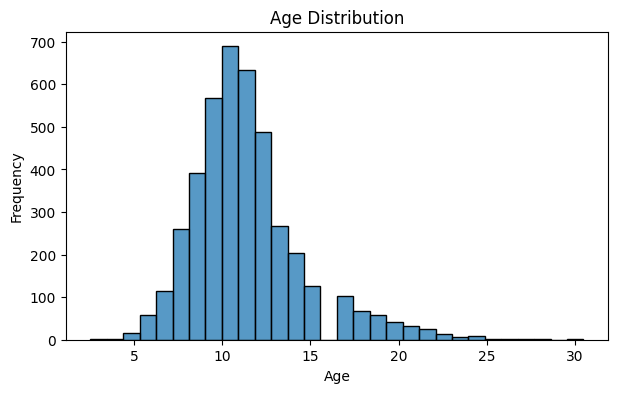

Age skewness: 1.1141


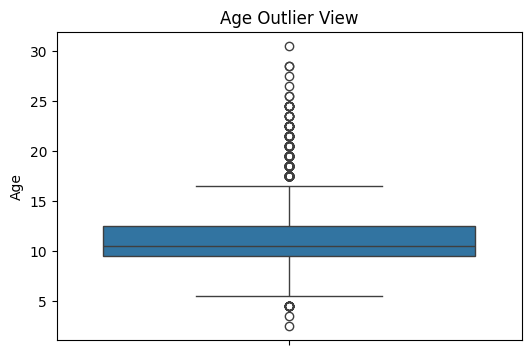

Average physical measurements by gender:
       Length  Diameter    Height  Whole_weight  Shucked_weight  \
Sex                                                               
F    0.579093  0.454732  0.158011      1.046532        0.446188   
I    0.427746  0.326494  0.107996      0.431363        0.191035   
M    0.561391  0.439287  0.151381      0.991459        0.432946   

     Viscera_weight  Shell_weight      Rings        Age  
Sex                                                      
F          0.230689      0.302010  11.129304  12.629304  
I          0.092010      0.128182   7.890462   9.390462  
M          0.215545      0.281969  10.705497  12.205497  


In [86]:
# Age distribution
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("Age skewness:", round(df["Age"].skew(), 4))

# Simple outlier view
plt.figure(figsize=(6,4))
sns.boxplot(df["Age"])
plt.title("Age Outlier View")
plt.ylabel("Age")
plt.show()

# Gender-wise measurements
print("Average physical measurements by gender:")
print(df.groupby("Sex").mean())

## Q3) How do you encode the `Sex` feature? Why one-hot encoding?
**Answer:** `Sex` is nominal, so one-hot encoding is preferred over label encoding.

In [87]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=["Sex"])
print(df_encoded.head())

   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings   Age  Sex_F  Sex_I  Sex_M  
0         0.150     15  16.5  False  False   True  
1         0.070      7   8.5  False  False   True  
2         0.210      9  10.5   True  False  False  
3         0.155     10  11.5  False  False   True  
4         0.055      7   8.5  False   True  False  


## Q4) Which physical features correlate most with age? Any redundancy?

In [88]:
corr = df_encoded.corr()["Age"].sort_values(ascending=False)
print("Correlation with Age:")
print(corr)

Correlation with Age:
Rings             1.000000
Age               1.000000
Shell_weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole_weight      0.540390
Viscera_weight    0.503819
Shucked_weight    0.420884
Sex_F             0.250279
Sex_M             0.181831
Sex_I            -0.436063
Name: Age, dtype: float64


## Q5) Why is scaling important? Compare with and without normalization

In [89]:
X = df_encoded.drop(["Age","Rings"], axis=1)
y = df_encoded["Age"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Without scaling
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Without Scaling")
print("MAE:", mean_absolute_error(y_test,pred))
print("MSE:", mean_squared_error(y_test,pred))

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_s, y_train)
pred2 = model2.predict(X_test_s)

print("With Scaling")
print("MAE:", mean_absolute_error(y_test,pred2))
print("MSE:", mean_squared_error(y_test,pred2))

Without Scaling
MAE: 1.593106781660834
MSE: 4.891232447128561
With Scaling
MAE: 1.5931067816608366
MSE: 4.891232447128581


### Why is there little or no difference with scaling?
- `LinearRegression` in scikit-learn uses ordinary least squares, which is scale-invariant for predictions.
- Scaling changes coefficient magnitudes, but the fitted line (and predictions) usually stays almost the same.
- So MAE and MSE are often equal or very close.
- Scaling matters more for models that use distance/gradients/regularization (e.g., KNN, SVM, neural networks, Ridge/Lasso).


## Q6) Build simple linear regression using one feature (`Shell_weight`) and comment on accuracy

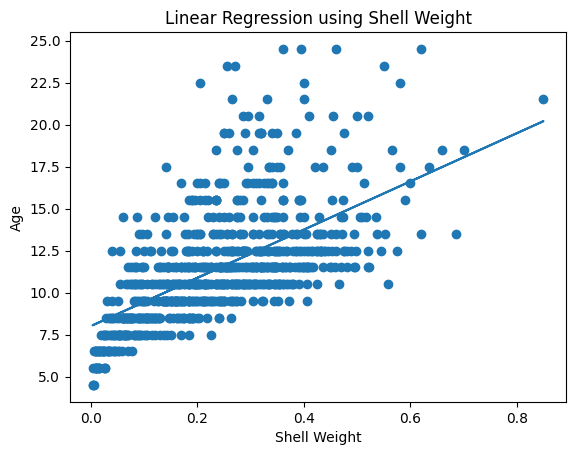


Simple Model MAE: 1.856075068032244


In [90]:
X_single = df[["Shell_weight"]]
y_single = df["Age"]

Xtr, Xte, ytr, yte = train_test_split(X_single,y_single,test_size=0.2,random_state=42)

simple_model = LinearRegression()
simple_model.fit(Xtr,ytr)

pred_simple = simple_model.predict(Xte)

plt.figure()
plt.scatter(Xte,yte)
plt.plot(Xte,pred_simple)
plt.title("Linear Regression using Shell Weight")
plt.xlabel("Shell Weight")
plt.ylabel("Age")
plt.show()

print("\nSimple Model MAE:", mean_absolute_error(yte,pred_simple))

## Q7) How does train/test split ratio affect performance?

In [91]:
for ratio in [0.1,0.2,0.3]:
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=ratio,random_state=42)
    model = LinearRegression()
    model.fit(Xtr,ytr)
    pred = model.predict(Xte)
    print(f"Test Size {ratio}")
    print("MAE:",mean_absolute_error(yte,pred))
    print("MSE:",mean_squared_error(yte,pred))

Test Size 0.1
MAE: 1.5644733425269637
MSE: 4.745915780163369
Test Size 0.2
MAE: 1.593106781660834
MSE: 4.891232447128561
Test Size 0.3
MAE: 1.583237738943726
MSE: 4.7847886426090955


## Q8) Final model evaluation using MAE and MSE

In [93]:
print("Final Model Evaluation:")
print("MAE:", mean_absolute_error(y_test,pred2))
print("MSE:", mean_squared_error(y_test,pred2))

Final Model Evaluation:
MAE: 1.5931067816608366
MSE: 4.891232447128581


## Q9) Is linear regression sufficient? What are limitations and better alternatives?
**Answer:** Linear regression is a baseline. Biological growth is often nonlinear, so models like Random Forest, Gradient Boosting, SVR, and Neural Networks can improve accuracy.